In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import talib
# import pynance as pn

In [5]:
# PyNance installation was attempted for additional financial metric analysis. However, compatibility issues were encountered due to dependency conflicts with newer Python and pandas versions. As a result, core financial metrics and technical indicators were computed using TA-Lib and pandas-based calculations instead.

In [6]:
df = pd.read_csv('../data/raw/AAPL.csv')
print(df.head())

         Date     Close      High       Low      Open      Volume
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [8]:
df['Date']=pd.to_datetime(df['Date'])
print(df.head())

        Date     Close      High       Low      Open      Volume
0 2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1 2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2 2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3 2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4 2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [9]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [7]:
df.set_index('Date', inplace=True)
print(df.head())

               Close      High       Low      Open      Volume
Date                                                          
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [10]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)

df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

print(df[['Close', 'SMA_20', 'SMA_50']].tail())

           Close      SMA_20      SMA_50
3769  191.788757  191.856618  183.572859
3770  191.243912  192.018094  183.858864
3771  191.342972  192.154308  184.149424
3772  191.768951  192.362839  184.479567
3773  190.728775  192.490633  184.814828


In [11]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

df['EMA_50'] = talib.EMA(df['Close'], timeperiod=50)

print(df[['Close', 'EMA_20', 'EMA_50']].tail())

           Close      EMA_20      EMA_50
3769  191.788757  191.510231  186.389576
3770  191.243912  191.484867  186.579942
3771  191.342972  191.471353  186.766728
3772  191.768951  191.499696  186.962893
3773  190.728775  191.426275  187.110575


In [12]:
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

df[['Close', 'RSI']].tail()

,Close,RSI
3769,191.788757,54.672784
3770,191.243912,53.090049
3771,191.342972,53.354446
3772,191.768951,54.540999
3773,190.728775,51.121347


In [13]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)
df[['MACD', 'MACD_signal', 'MACD_hist']].tail()

,MACD,MACD_signal,MACD_hist
3769,2.633141,3.235256,-0.602115
3770,2.304751,3.049155,-0.744404
3771,2.029104,2.845145,-0.816041
3772,1.823998,2.640915,-0.816918
3773,1.559539,2.424640,-0.865101


In [15]:
print(df.tail())

           Date       Close        High         Low        Open    Volume  \
3769 2023-12-22  191.788757  193.581821  191.164647  193.353962  37149600   
3770 2023-12-26  191.243912  192.076049  191.025969  191.798670  28919300   
3771 2023-12-27  191.342972  191.689703  189.302247  190.689158  48087700   
3772 2023-12-28  191.768951  192.838849  191.362784  192.323710  34049900   
3773 2023-12-29  190.728775  192.581275  189.936256  192.085953  42672100   

          SMA_20      SMA_50      EMA_20      EMA_50        RSI      MACD  \
3769  191.856618  183.572859  191.510231  186.389576  54.672784  2.633141   
3770  192.018094  183.858864  191.484867  186.579942  53.090049  2.304751   
3771  192.154308  184.149424  191.471353  186.766728  53.354446  2.029104   
3772  192.362839  184.479567  191.499696  186.962893  54.540999  1.823998   
3773  192.490633  184.814828  191.426275  187.110575  51.121347  1.559539   

      MACD_signal  MACD_hist  
3769     3.235256  -0.602115  
3770     3.0

In [ ]:
# # Technical Indicator Analysis
#
# Several technical indicators were computed using TA-Lib to analyze Apple stock price behavior and market momentum.
#
# Simple Moving Averages (SMA) and Exponential Moving Averages (EMA) were calculated using 20-day and 50-day windows to identify short-term and long-term market trends. The moving averages showed that Apple stock maintained an overall upward trend during the analyzed period, although some short-term price fluctuations were observed.
#
# The Relative Strength Index (RSI) was used to evaluate market momentum and potential overbought or oversold conditions. RSI values remained mostly around the neutral range near 50, suggesting balanced market conditions without strong overbought or oversold signals.
#
# The Moving Average Convergence Divergence (MACD) indicator was used to analyze momentum changes and possible trend reversals. The MACD histogram showed several negative values near the end of the observed period, indicating weakening bullish momentum and the possibility of short-term bearish pressure.
#
# Overall, the technical indicators provided useful insight into trend direction, market momentum, and potential reversal behavior within the Apple stock price series.

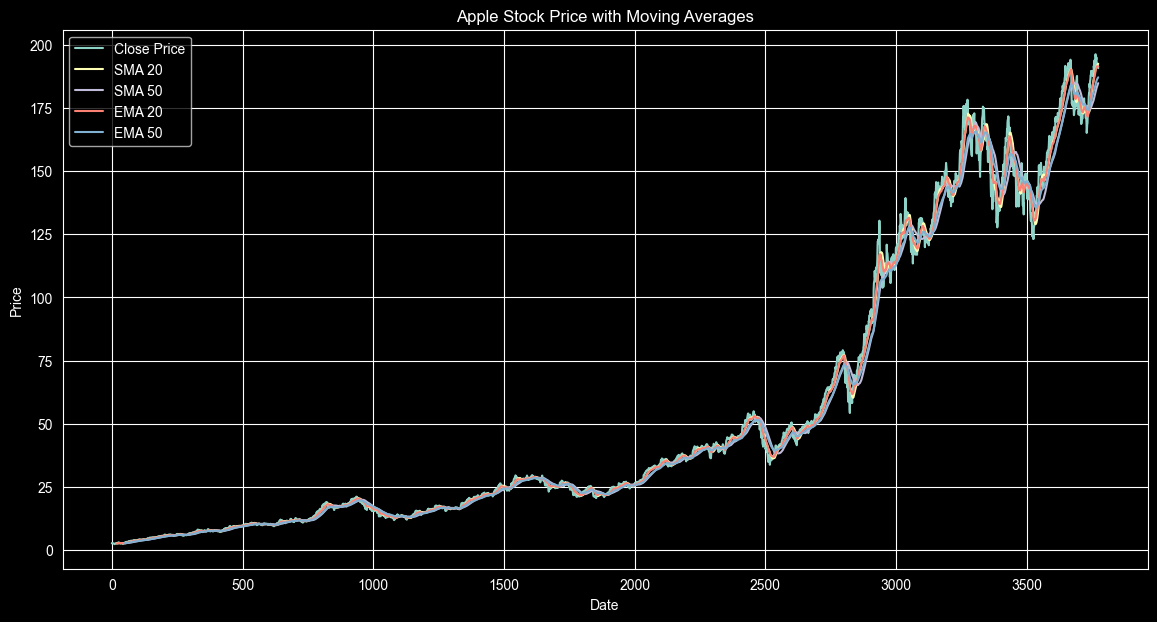

In [16]:
plt.figure(figsize=(14,7))
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.plot(df.index, df['SMA_50'], label='SMA 50')
plt.plot(df.index, df['EMA_20'], label='EMA 20')
plt.plot(df.index, df['EMA_50'], label='EMA 50')

plt.title('Apple Stock Price with Moving Averages')

plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
# ## Interpretation of Moving Average Trends
#
# The moving average visualization revealed a strong long-term upward trend in Apple stock prices over the observed period. Both SMA and EMA indicators followed the overall increase in price, confirming sustained bullish market behavior.
#
# The 20-period moving averages reacted more quickly to short-term price fluctuations compared to the smoother 50-period averages, demonstrating their higher responsiveness to recent market activity. In the later portion of the timeline, the shorter-term averages generally remained above the longer-term averages, which is commonly interpreted as a sign of continued positive momentum.
#
# The chart also showed periods where the stock price temporarily pulled back toward the moving average lines before recovering, suggesting that the moving averages may have acted as dynamic support levels during upward market trends.

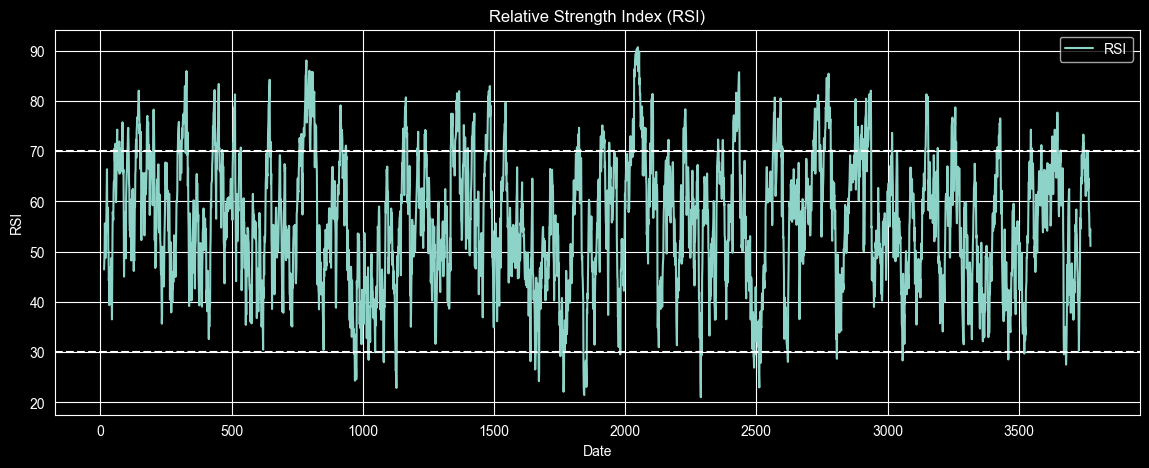

In [17]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df['RSI'], label='RSI')
plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

In [ ]:
# ## Interpretation of RSI Trends
#
# The RSI visualization showed frequent fluctuations between overbought and oversold zones, reflecting changing market momentum throughout the analyzed period.
#
# A particularly strong overbought condition was observed when the RSI exceeded 90, indicating an unusually intense buying period that may not have been sustainable in the short term. In the later portion of the dataset, the RSI remained mostly above the neutral 50 level, supporting the broader bullish trend observed in the stock price and moving average analysis.
#
# Overall, the RSI analysis suggests that Apple stock experienced strong positive momentum during several periods while maintaining relatively balanced market conditions for much of the observed timeline.

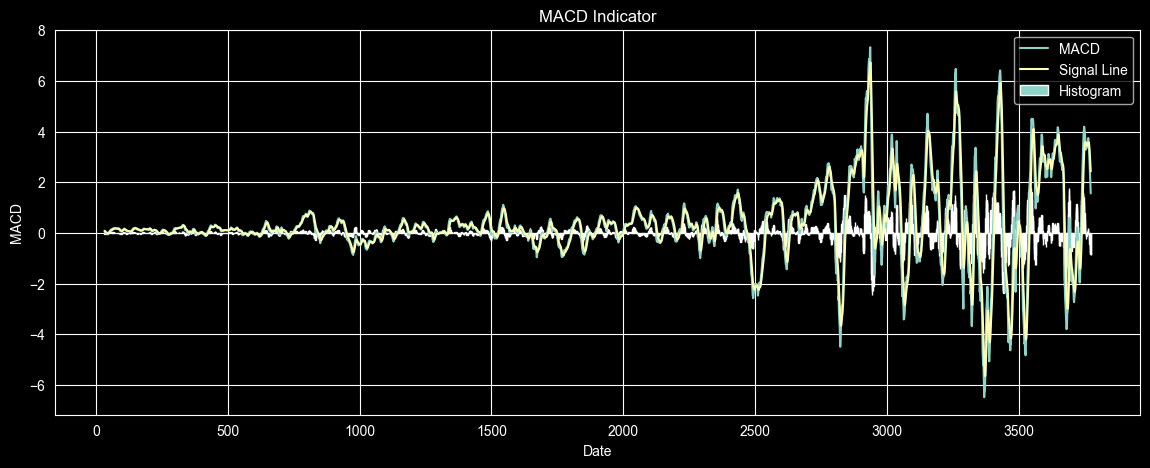

In [18]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal Line')
plt.bar(df.index, df['MACD_hist'], label='Histogram')
plt.title('MACD Indicator')

plt.xlabel('Date')
plt.ylabel('MACD')

plt.legend()
plt.show()

In [ ]:
# ## Interpretation of MACD Trends
#
# The MACD visualization revealed changing momentum conditions across the historical stock price series. During the earlier portion of the timeline, the MACD remained relatively stable and close to the zero line, suggesting lower volatility and gradual price growth.
#
# In the later stages of the dataset, the MACD displayed significantly larger fluctuations, indicating increased market volatility and stronger momentum shifts. Several major positive spikes reflected periods of strong bullish momentum, while sharp negative declines suggested temporary bearish pressure and possible short-term corrections.
#
# The increasing volatility observed in the MACD analysis aligns with the trends identified in both the RSI and moving average visualizations, confirming stronger market activity and momentum changes during the later years of the dataset.